# Retrieval benchmark — eight methods

This section isolates retrieval and metadata-aware reranking. It does not generate answers, run RAGAS, ingest documents, or rebuild the index. Run the cells in order from a fresh kernel.

| ID | Method | What changes |
|---:|---|---|
| 1 | Unfiltered hybrid baseline | Dense and BM25 retrieval with no metadata filter. |
| 2 | Ticker filtering | Searches each ticker separately, then interleaves the results. |
| 3 | Ticker + reporting period | Adds form type and period-end filters to the ticker search. |
| 5 | SEC rewrite + period filters | Rewrites the full question in filing terminology before method 3. |
| 9 | Ticker-filtered subqueries | Splits the question into atomic facets and retrieves 10 chunks per facet. |
| 15 | Rewrite + ticker subqueries | Rewrites the question, then plans and retrieves its facets. |
| 18 | Fixed-depth facets @50 | Uses semantic and filing queries per facet, fuses them with RRF, and caps the pool at 50. |
| 20 | Confidence-routed backfill @75 | Routes strong facet agreement to likely filings and progressively deepens retrieval to 75. |

All methods use the same scoped questions, index, embeddings, hybrid search, and BGE reranker. This keeps the comparison focused on query construction and filtering.

**Cost and cache behavior:** planning, rewriting, and embeddings use OpenRouter; BGE runs locally. The first run is expensive, but completed stages are stored on disk and reused after interruption. The existing index and saved outputs remain unchanged.

To run the answer-generation evaluation instead, skip to **Independent experiment 3**. Using **Run All** executes both sections and may trigger paid calls.


In [1]:
# Locate the repository so the notebook also works when opened from its own folder.
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

start = Path.cwd().resolve()
project_root = next((p for p in (start, *start.parents) if (p / "src" / "RAG_model").is_dir()), None)
if project_root is None:
    raise RuntimeError("Could not locate the project root.")
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

# Keep benchmark logic in tested modules; this notebook only configures and presents it.
from RAG_model.model_analysis_notebooks.utils.evidence import load_evaluation_questions, EVIDENCE_METRIC_VERSION
from RAG_model.model_analysis_notebooks.utils.retrieval_benchmark import Benchmark, STRATEGIES, DEFAULT_SETTINGS, source_scope


In [2]:
# Stable paths let interrupted runs resume from the same stage caches.
DATASET_PATH = project_root / "data/rag_evaluation/evaluation_questions_v4.csv"
CACHE_DIRECTORY = project_root / "data/rag_evaluation/results/retrieval_benchmark/cache"
RUN_DIRECTORY = project_root / "data/rag_evaluation/results/retrieval_benchmark/runs"
settings = dict(DEFAULT_SETTINGS)

# Retrieval recall is defined only for the 32 answerable questions.
questions = load_evaluation_questions(DATASET_PATH)
answerable = questions[questions["answerable"].map(lambda v: str(v).lower() in {"true", "1"})].copy()
assert len(answerable) == 32, f"Expected 32 answerable questions, found {len(answerable)}."
assert [s["id"] for s in STRATEGIES] == [1, 2, 3, 5, 9, 15, 18, 20]
for question in answerable["question"]:
    source_scope(question)
print(f"Dataset: {DATASET_PATH.name}; {len(answerable)} answerable questions; {len(STRATEGIES)} strategies.")
print(f"Metric: {EVIDENCE_METRIC_VERSION}; exact accession; threshold 0.85.")
print(f"Cache: {CACHE_DIRECTORY}")
print("No model calls have been made by setup.")


Dataset: evaluation_questions_v4.csv; 32 answerable questions; 8 strategies.
Metric: adjacent-pair-v1; exact accession; threshold 0.85.
Cache: C:\Users\david\Documents\Projects\crypto_chatbot_rag\data\rag_evaluation\results\retrieval_benchmark\cache
No model calls have been made by setup.


## Evaluation contract and code map

A claim succeeds only when **all** its annotated evidence passages are supported. Evidence must match the **exact accession**, with ordered token coverage at least **0.85**, in one selected chunk or two consecutive narrative chunks from the same filing and section. Both adjacent chunks must already be inside the evaluated top-k. The evaluator never retrieves extra context.

The versioned dataset explicitly states ticker, filing form, and reporting period. Q19 has different scopes for its two tickers. Gold claims, evidence and accessions are used only for evaluation.

**Raw @15/@20/@50/@75 are prefixes of one candidate retrieval**, not independent searches or latency measurements at each k. Experiment 18 is capped at 50, so @75 is N/A. Variable strategies may return fewer than k; pool counts expose this. Metadata @15/@20 are prefixes of one full-pool BGE ranking per experiment.

All primary recall columns are **claim-weighted**. Equal-category means and minimum-category recall are also included in the overall table. A minimum-category recall above 0.60 is the stronger success criterion.

The original single-chunk metric is preserved in `claim_results.csv` and `evidence_results.csv` under `legacy_single`. Historical and corrected scores must not be mixed because the evaluation contract changed.

The implementation is intentionally separated from the notebook:

- `source_scope()` reads ticker, form, and reporting-period constraints from the question text.
- `Benchmark.rewrite()` creates one SEC-style query without answering the question.
- `Benchmark.plan()` creates validated atomic facets with complete ticker coverage.
- `Benchmark.search()` performs cached dense + BM25 hybrid retrieval with the requested filters.
- `Benchmark.route()` selects likely accessions only when facet agreement reaches the confidence threshold.
- `Benchmark.retrieve()` builds the candidate pool for each method.
- `Benchmark.rerank()` applies BGE to the same candidate membership.
- `evaluate_claim_evidence()` checks claim support; `summary_tables()` aggregates the saved results.


In [3]:
# Execute all eight methods. The first run is expensive; later runs resume from disk.
# Completed stages survive interruption or kernel/PC shutdown.
benchmark = Benchmark(project_root, settings=settings, cache_dir=CACHE_DIRECTORY)
result = benchmark.run(questions, output_dir=RUN_DIRECTORY)
overall_results = result["overall"]
category_results = result["category"]
print("Saved results:", result["directory"])


Candidate pools cached: 0/256. Missing: 256. Metadata rankings are checked per pool.
Q1 experiment 1: checking retrieval and ranking caches...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

1/256: Q1 experiment 1 — 75 candidates; pool computed, rerank computed
Q1 experiment 2: checking retrieval and ranking caches...
2/256: Q1 experiment 2 — 75 candidates; pool computed, rerank computed
Q1 experiment 3: checking retrieval and ranking caches...
3/256: Q1 experiment 3 — 75 candidates; pool computed, rerank computed
Q1 experiment 5: checking retrieval and ranking caches...
4/256: Q1 experiment 5 — 75 candidates; pool computed, rerank computed
Q1 experiment 9: checking retrieval and ranking caches...
5/256: Q1 experiment 9 — 16 candidates; pool computed, rerank computed
Q1 experiment 15: checking retrieval and ranking caches...
6/256: Q1 experiment 15 — 21 candidates; pool computed, rerank computed
Q1 experiment 18: checking retrieval and ranking caches...
7/256: Q1 experiment 18 — 18 candidates; pool computed, rerank computed
Q1 experiment 20: checking retrieval and ranking caches...
8/256: Q1 experiment 20 — 66 candidates; pool computed, rerank computed
Q2 experiment 1: che

## Saved results and rerunning

Wait for **RETRIEVAL_BENCHMARK_SAVE_COMPLETE** before treating the comparison as complete. Each question/strategy result is checkpointed, with candidates, rankings, plans/routes, and per-facet provenance. If a run fails, inspect its `failures.json`, resolve the cause and use Run All again; completed stages are reused. An incomplete run never produces a completed comparison table.

Each run saves a manifest plus overall, category, question, claim, and evidence CSVs. Source/model/settings/question/collection changes invalidate relevant caches; evidence-only changes reuse retrieval and ranking.

Timing columns distinguish **saved stage computation durations** from **cache loading** and **wall time on this execution**. Saved retrieval durations are measured when that pool was created, and can include reuse of intermediate caches; they are not guaranteed cold end-to-end latency. Reranker time is separate. Cache reload time is not model latency.

Once successful, all remaining cells below are local table rendering and can be repeated without API or model calls.


In [4]:
# Use one display format for both saved summary tables.
recall_columns = [
    "claim_recall_pool", "claim_recall_raw_15", "claim_recall_raw_20",
    "claim_recall_raw_50", "claim_recall_raw_75",
    "claim_recall_metadata_15", "claim_recall_metadata_20",
]
timing_columns = [
    "mean_retrieval_saved_seconds", "mean_rerank_saved_seconds",
    "mean_cache_load_seconds", "mean_wall_seconds_this_run",
]
overall_columns = [
    "strategy", "mean_candidate_count", "underfilled_questions", *recall_columns,
    "category_mean_metadata_20", "category_min_metadata_20", *timing_columns,
]
category_columns = [
    "strategy", "category", "mean_candidate_count", "underfilled_questions",
    *recall_columns, *timing_columns,
]
formats = {column: "{:.4f}" for column in recall_columns}
formats.update({column: "{:.3f}" for column in timing_columns})
formats.update({"mean_candidate_count": "{:.1f}", "category_mean_metadata_20": "{:.4f}",
                "category_min_metadata_20": "{:.4f}"})

def highlight_category_maxima(frame):
    styles = pd.DataFrame("", index=frame.index, columns=frame.columns)
    for _, indexes in frame.groupby("category").groups.items():
        for column in recall_columns:
            best = frame.loc[indexes, column].max()
            styles.loc[indexes, column] = [
                "background-color: #c6efce; color: #006100" if value == best else ""
                for value in frame.loc[indexes, column]
            ]
    return styles


## Overall comparison


In [5]:
# One row per method across all answerable questions.
display(
    overall_results[overall_columns].style.format(formats, na_rep="N/A")
    .highlight_max(subset=recall_columns, color="#c6efce")
)


,strategy,mean_candidate_count,underfilled_questions,claim_recall_pool,claim_recall_raw_15,claim_recall_raw_20,claim_recall_raw_50,claim_recall_raw_75,claim_recall_metadata_15,claim_recall_metadata_20,category_mean_metadata_20,category_min_metadata_20,mean_retrieval_saved_seconds,mean_rerank_saved_seconds,mean_cache_load_seconds,mean_wall_seconds_this_run
0,1. Unfiltered hybrid baseline,75.0,0,0.5148,0.3609,0.3846,0.4911,0.5148,0.4201,0.4556,0.5056,0.2000,1.548,64.859,0.000,66.528
1,2. Ticker filtering,75.0,0,0.6095,0.3787,0.3964,0.5207,0.6095,0.4675,0.5030,0.5479,0.2727,0.611,69.136,0.000,69.909
2,3. Ticker + reporting-period filtering,75.0,0,0.8343,0.6331,0.6686,0.7811,0.8343,0.6805,0.6982,0.7350,0.4909,0.665,71.445,0.000,72.675
3,5. SEC rewrite + ticker + reporting-period,75.0,0,0.8402,0.6095,0.6154,0.7988,0.8402,0.6805,0.7101,0.7450,0.5091,4.504,69.267,0.000,69.588
4,9. Ticker-filtered variable subqueries,40.5,29,0.3728,0.1775,0.1775,0.3728,0.3728,0.3314,0.3491,0.3702,0.2609,17.452,39.729,0.000,57.285
5,15. Rewrite + ticker variable subqueries,36.6,30,0.4142,0.1893,0.2544,0.4142,0.4142,0.3787,0.3787,0.4165,0.2000,15.144,37.518,0.000,52.768
6,18. Legacy fixed-depth facets @50,35.5,26,0.5148,0.3314,0.4024,0.5148,N/A,0.4911,0.5030,0.5345,0.3455,19.197,34.497,0.000,53.783
7,20. Legacy confidence backfill @75,74.5,3,0.6627,0.3669,0.4852,0.6391,0.6627,0.5503,0.5680,0.6070,0.3455,12.156,65.807,0.000,78.155


## Comparison by question category


In [6]:
# One row per method and question category; no retrieval is repeated here.
display(
    category_results[category_columns].style.format(formats, na_rep="N/A")
    .apply(highlight_category_maxima, axis=None)
)


,strategy,category,mean_candidate_count,underfilled_questions,claim_recall_pool,claim_recall_raw_15,claim_recall_raw_20,claim_recall_raw_50,claim_recall_raw_75,claim_recall_metadata_15,claim_recall_metadata_20,mean_retrieval_saved_seconds,mean_rerank_saved_seconds,mean_cache_load_seconds,mean_wall_seconds_this_run
0,1. Unfiltered hybrid baseline,Comparison,75.0,0,0.4130,0.1739,0.1739,0.3478,0.4130,0.2174,0.3261,1.132,62.200,0.000,63.424
1,1. Unfiltered hybrid baseline,Factual,75.0,0,0.7632,0.6053,0.7105,0.7368,0.7632,0.7368,0.7632,3.273,63.938,0.000,67.331
2,1. Unfiltered hybrid baseline,Procedural,75.0,0,0.7333,0.6333,0.6333,0.7333,0.7333,0.7333,0.7333,0.923,74.072,0.000,75.134
3,1. Unfiltered hybrid baseline,Synthesis,75.0,0,0.3091,0.2000,0.2000,0.3091,0.3091,0.2000,0.2000,0.863,59.224,0.000,60.222
4,2. Ticker filtering,Comparison,75.0,0,0.5435,0.1739,0.1957,0.3478,0.5435,0.2391,0.3696,0.878,64.313,0.000,65.326
5,2. Ticker filtering,Factual,75.0,0,0.8684,0.6053,0.6316,0.8421,0.8684,0.8158,0.8158,0.452,66.539,0.000,67.137
6,2. Ticker filtering,Procedural,75.0,0,0.7667,0.7333,0.7333,0.7333,0.7667,0.7333,0.7333,0.503,85.679,0.000,86.351
7,2. Ticker filtering,Synthesis,75.0,0,0.4000,0.2000,0.2182,0.3273,0.4000,0.2727,0.2727,0.611,60.014,0.000,60.820
8,3. Ticker + reporting-period filtering,Comparison,75.0,0,0.7391,0.5435,0.5870,0.6739,0.7391,0.5652,0.6087,0.932,67.123,0.000,68.464
9,3. Ticker + reporting-period filtering,Factual,75.0,0,1.0000,0.9737,0.9737,1.0000,1.0000,0.9737,0.9737,0.476,68.166,0.000,69.198


## Conclusions 

Based on the previous results, we can conclude that Experiment 3 is the most promising configuration to continue iterating on. Therefore, we will use Experiment 3 as the baseline for generating the full results (retrieval + generation) under four configurations: with and without a reranker, and with 15 and 20 retrieved chunks.

The goal is to determine whether the Experiment 3 configuration can consistently maintain good performance while considering the trade-offs between retrieval quality, token usage, and latency.


# Independent experiment 3 — retrieval and answer generation

**Start here after restarting the kernel. Run only this section's cells, in order. No earlier cell or live variable is required.** The existing index and scoped dataset are required; historical result caches are optional optimizations.

This experiment compares four configurations: direct retrieval at 15 and 20 chunks, each with the raw hybrid order and the metadata-aware BGE order. Raw and reranked pairs contain the same chunks, so this tests ordering rather than retrieval coverage. Multi-ticker results are merged round-robin.

All **40 questions × four configurations = 160 evaluations** use the same generator, prompt, and RAGAS judge. The section does not modify production retrieval, ingest documents, or rebuild the index.


In [4]:
# Independent setup: no variables from the retrieval-only section are required.
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

full_start = Path.cwd().resolve()
full_root = next((p for p in (full_start, *full_start.parents) if (p / "src/RAG_model").is_dir()), None)
if full_root is None:
    raise RuntimeError("Could not locate the project root.")
if str(full_root / "src") not in sys.path:
    sys.path.insert(0, str(full_root / "src"))
from RAG_model.model_analysis_notebooks.utils.evidence import load_evaluation_questions
from RAG_model.model_analysis_notebooks.utils.full_benchmark import FullBenchmark, VARIANTS

full_dataset_path = full_root / "data/rag_evaluation/evaluation_questions_v4.csv"
full_output_root = full_root / "data/rag_evaluation/results/experiment3_full_evaluation"
# Fix generation and evaluation settings so retrieval order is the only variable.
full_settings = {
    "generation_model": "openai/gpt-5.6-luna", "temperature": 0,
    "generation_max_tokens": 1000, "prompt_version": "v2",
    "ragas_evaluator_model": "openai/gpt-5.6-terra", "ragas_temperature": 0,
    "answer_correct_threshold": 0.70,
}
full_questions = load_evaluation_questions(full_dataset_path)
assert len(full_questions) == 40 and full_questions.question_id.nunique() == 40
assert full_questions.answerable.map(lambda x: str(x).lower() in {"true", "1"}).sum() == 32
assert len(VARIANTS) == 4
print("Ready: 40 questions, 4 configurations. Setup made no API/model calls.")
print("Results and checkpoints:", full_output_root)


Ready: 40 questions, 4 configurations. Setup made no API/model calls.
Results and checkpoints: C:\Users\david\Documents\Projects\crypto_chatbot_rag\data\rag_evaluation\results\experiment3_full_evaluation


## Metrics and execution cost

- **Answerable questions:** retrieval recall/MRR plus RAGAS faithfulness, factual correctness in recall mode, and context precision. An answer passes at factual correctness ≥ 0.70.
- **Unanswerable questions:** exact-match abstention accuracy. Retrieval and RAGAS metrics are N/A, not zero.
- **Citation validity:** cited source IDs must exist in the retrieved context; this does not test whether a citation entails the claim.
- **Total latency:** retrieval + reranking + prompt construction + generation. Evaluation and export time are reported separately. Cached stage timings produce reconstructed latency rather than a fresh end-to-end measurement.

Gold fields are used only after generation for evaluation. A cold run may execute 160 generations and 384 RAGAS evaluations. Exact inputs are cached. A generation truncated at 1,000 tokens receives one retry at 2,000 tokens.


In [3]:
# Paid generation/RAGAS and local BGE run ONLY when you execute this cell.
# Rerun after interruption: completed stages are loaded from disk.
import json
from importlib import reload
from RAG_model.model_analysis_notebooks.utils import full_benchmark as full_benchmark_module

# Reload only the real module class so the adaptive retry is available without a
# kernel restart. Test or injected benchmark factories remain intact.
if getattr(full_benchmark_module.FullBenchmark, "__module__", None) == full_benchmark_module.__name__:
    full_benchmark_module = reload(full_benchmark_module)
FullBenchmark = full_benchmark_module.FullBenchmark

# A compatible code fix must retain the incomplete run's implementation identity;
# otherwise its 120 completed generation/RAGAS checkpoints would receive new keys.
resume_candidates = []
for manifest_path in (full_output_root / "runs").glob("*/manifest.json"):
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    if manifest.get("status") == "incomplete" and manifest.get("expected_results") == 160:
        resume_candidates.append((manifest_path.stat().st_mtime, manifest_path, manifest))
resume_record = max(resume_candidates, default=None, key=lambda item: item[0])
resume_manifest = resume_record[2] if resume_record else None

full_benchmark = FullBenchmark(
    full_root,
    settings=full_settings,
    cache_dir=full_output_root / "cache",
    retrieval_cache_dir=full_root / "data/rag_evaluation/results/retrieval_benchmark/cache",
    implementation_identity=resume_manifest.get("implementation") if resume_manifest else None,
    generation_retry_max_tokens=2000,
)

# The known failed key has already reached the 1,000-token limit twice. Register it
# to go directly to 2,000 tokens. All other missing generations start at 1,000 and
# automatically retry at 2,000 only if their first response also ends by length.
if resume_manifest:
    failure = resume_manifest.get("last_failure") or {}
    if failure.get("stage") == "generation" and "finish_reason=length" in failure.get("error", ""):
        failed_question = full_questions.loc[
            full_questions["question_id"].eq(failure["question_id"])
        ].iloc[0]
        failed_pool, _ = full_benchmark.pool(
            failed_question["question"], int(failure["candidate_cap"])
        )
        failed_chunks = failed_pool["candidates"]
        if str(failure.get("variant", "")).endswith("_reranked") and failed_chunks:
            failed_chunks, _ = full_benchmark.retrieval.rerank(
                failed_question["question"], failed_chunks
            )
        _, failed_generation_key = full_benchmark.messages_and_key(
            failed_question["question"], failed_chunks
        )
        full_benchmark.force_retry_generation_keys.add(
            full_benchmark_module.digest(failed_generation_key)
        )
        print(
            "Resuming compatible run after",
            resume_manifest["completed_results"],
            "of",
            resume_manifest["expected_results"],
            "results; the failed generation will use 2,000 tokens directly.",
        )

full_result = await full_benchmark.run(
    full_questions, output_dir=full_output_root / "runs"
)
full_overall = full_result["overall"]
full_category = full_result["category"]
print("Saved completed evaluation:", full_result["directory"])

Independent experiment 3: {"questions": 40, "variant_results": 160, "stages": {"pool": {"cached": 1, "missing": 79, "inputs_pending": 0}, "reranking": {"cached": 0, "missing": 1, "inputs_pending": 79}, "generation": {"cached": 1, "missing": 0, "inputs_pending": 159}, "ragas_metric": {"cached": 3, "missing": 0, "inputs_pending": 381}}, "note": "Counts are per requested evaluation before identical-input deduplication; empty pools need no BGE."}
Inputs pending means upstream work is needed to determine the exact cache key. No old cells required.
Q1 direct_15_raw: 15 candidates; checking stage caches
1/160 complete; checkpoint saved
Q1 direct_15_reranked: 15 candidates; checking stage caches


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

CancelledError: 

## Saved results and comparison tables

Wait for **EXPERIMENT3_FULL_EVALUATION_SAVE_COMPLETE** before using the tables. Each question/configuration, generation, metric, and timing is checkpointed independently, so an interrupted run resumes without repeating completed work. Failures remain under `failures/` for inspection.

A completed run saves overall, category, and question CSVs, detailed question JSONs, `results.json`, and a manifest.

**To showcase the existing results without rerunning the evaluation:** start with the next cell, then run the table setup, overall table, charts, and category table. Do not run the paid execution cell above.


In [5]:
# Start here to display the latest completed Experiment 3 without rerunning it.
from pathlib import Path
import json
import pandas as pd

saved_start = Path.cwd().resolve()
saved_root = next((p for p in (saved_start, *saved_start.parents) if (p / "src" / "RAG_model").is_dir()), None)
if saved_root is None:
    raise RuntimeError("Could not locate the project root.")

saved_runs = saved_root / "data/rag_evaluation/results/experiment3_full_evaluation/runs"
completed_runs = []
for manifest_path in saved_runs.glob("*/manifest.json"):
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    run_directory = manifest_path.parent
    if (
        manifest.get("status") == "complete"
        and manifest.get("completed_results") == manifest.get("expected_results") == 160
        and (run_directory / "overall_results.csv").exists()
        and (run_directory / "category_results.csv").exists()
    ):
        completed_runs.append((manifest_path.stat().st_mtime, run_directory, manifest))

if not completed_runs:
    raise FileNotFoundError("No completed 160-result Experiment 3 run was found.")

_, latest_full_run, latest_full_manifest = max(completed_runs, key=lambda item: item[0])
full_overall = pd.read_csv(latest_full_run / "overall_results.csv")
full_category = pd.read_csv(latest_full_run / "category_results.csv")
print(f"Loaded saved Experiment 3: {latest_full_run.name} (160/160 results).")
print("No retrieval, generation, reranking, or RAGAS calls were made.")


Loaded saved Experiment 3: 705a1b9455c7fc45c500 (160/160 results).
No retrieval, generation, reranking, or RAGAS calls were made.


In [6]:
# Keep the presentation order stable when cached results are reloaded.
full_primary_columns = [
    "variant", "candidate_cap", "rerank", "completed_questions", "failed_questions",
    "answerable_questions", "unanswerable_questions",
    "claim_recall", "legacy_claim_recall", "document_hit_rate", "document_recall", "mrr",
    "mean_ragas_faithfulness", "mean_ragas_factual_correctness", "mean_ragas_context_precision",
    "answerable_threshold_accuracy", "abstention_accuracy", "incorrect_abstention_rate",
    "overall_mixed_accuracy", "citation_validity_rate",
    "mean_total_latency_ms", "p95_total_latency_ms",
    "mean_retrieval_latency_ms", "mean_reranking_latency_ms", "mean_prompt_latency_ms",
    "mean_generation_latency_ms", "mean_evaluation_latency_ms", "mean_evaluation_saved_ms",
    "mean_cache_load_ms", "mean_wall_ms_this_execution", "reconstructed_latency_questions",
    "mean_candidate_count", "mean_context_count", "underfilled_questions", "empty_pools",
    "mean_generation_input_tokens", "mean_generation_output_tokens", "mean_generation_total_tokens",
    "mean_embedding_tokens", "mean_rag_total_tokens",
]
full_balance_columns = [c for c in full_overall.columns if c.startswith(("category_mean_", "category_min_"))]
full_formats = {c: "{:.3f}" for c in full_overall.select_dtypes(include="float").columns}


## Full evaluation — overall comparison (four configurations)


In [7]:
# Overall results: one row per retrieval configuration.
display(full_overall[full_primary_columns + full_balance_columns].style.format(full_formats, na_rep="N/A"))


,variant,candidate_cap,rerank,completed_questions,failed_questions,answerable_questions,unanswerable_questions,claim_recall,legacy_claim_recall,document_hit_rate,document_recall,mrr,mean_ragas_faithfulness,mean_ragas_factual_correctness,mean_ragas_context_precision,answerable_threshold_accuracy,abstention_accuracy,incorrect_abstention_rate,overall_mixed_accuracy,citation_validity_rate,mean_total_latency_ms,p95_total_latency_ms,mean_retrieval_latency_ms,mean_reranking_latency_ms,mean_prompt_latency_ms,mean_generation_latency_ms,mean_evaluation_latency_ms,mean_evaluation_saved_ms,mean_cache_load_ms,mean_wall_ms_this_execution,reconstructed_latency_questions,mean_candidate_count,mean_context_count,underfilled_questions,empty_pools,mean_generation_input_tokens,mean_generation_output_tokens,mean_generation_total_tokens,mean_embedding_tokens,mean_rag_total_tokens,category_mean_claim_recall,category_min_claim_recall,category_mean_mean_ragas_faithfulness,category_min_mean_ragas_faithfulness,category_mean_mean_ragas_factual_correctness,category_min_mean_ragas_factual_correctness,category_mean_mean_ragas_context_precision,category_min_mean_ragas_context_precision
0,direct_15_raw,15,False,40,0,32,8,0.639,0.615,1.000,1.000,0.914,0.908,0.783,0.677,0.781,1.000,0.062,0.825,0.925,6259.391,20362.930,1851.507,0.000,0.027,4407.856,5417.324,70572.203,1.738,6834.955,32,13.875,13.875,3,3,7158.900,312.625,7471.525,N/A,N/A,0.687,0.364,0.908,0.793,0.783,0.596,0.677,0.598
1,direct_15_reranked,15,True,40,0,32,8,0.639,0.615,1.000,1.000,0.914,0.892,0.745,0.820,0.750,1.000,0.062,0.800,0.950,26108.560,46157.943,1851.507,20130.583,0.030,4126.440,4812.563,71639.639,3.338,10351.466,40,13.875,13.875,3,3,7158.900,294.275,7453.175,N/A,N/A,0.687,0.364,0.892,0.794,0.745,0.499,0.820,0.731
2,direct_20_raw,20,False,40,0,32,8,0.657,0.633,1.000,1.000,0.914,0.964,0.765,0.646,0.781,1.000,0.000,0.825,1.000,6402.275,19698.271,1834.923,0.000,0.042,4567.310,6402.389,88399.945,3.401,8423.872,40,18.500,18.500,3,3,9374.825,347.225,9722.050,N/A,N/A,0.701,0.418,0.964,0.917,0.765,0.683,0.646,0.570
3,direct_20_reranked,20,True,40,0,32,8,0.657,0.633,1.000,1.000,0.914,0.965,0.826,0.806,0.781,1.000,0.000,0.825,1.000,33720.739,59408.853,1834.923,27434.540,0.063,4451.214,5803.498,86733.399,3.698,13772.559,40,18.500,18.500,3,3,9374.825,330.500,9705.325,N/A,N/A,0.701,0.418,0.965,0.910,0.826,0.713,0.806,0.716


## Full evaluation — visual comparison of the most important metrics

These charts use only the overall experiment results; category-level rows are not included. The most important metrics appear first from the top-left. Green identifies the best observed configuration for each metric. Higher is better for quality metrics, while lower is better for p95 latency.


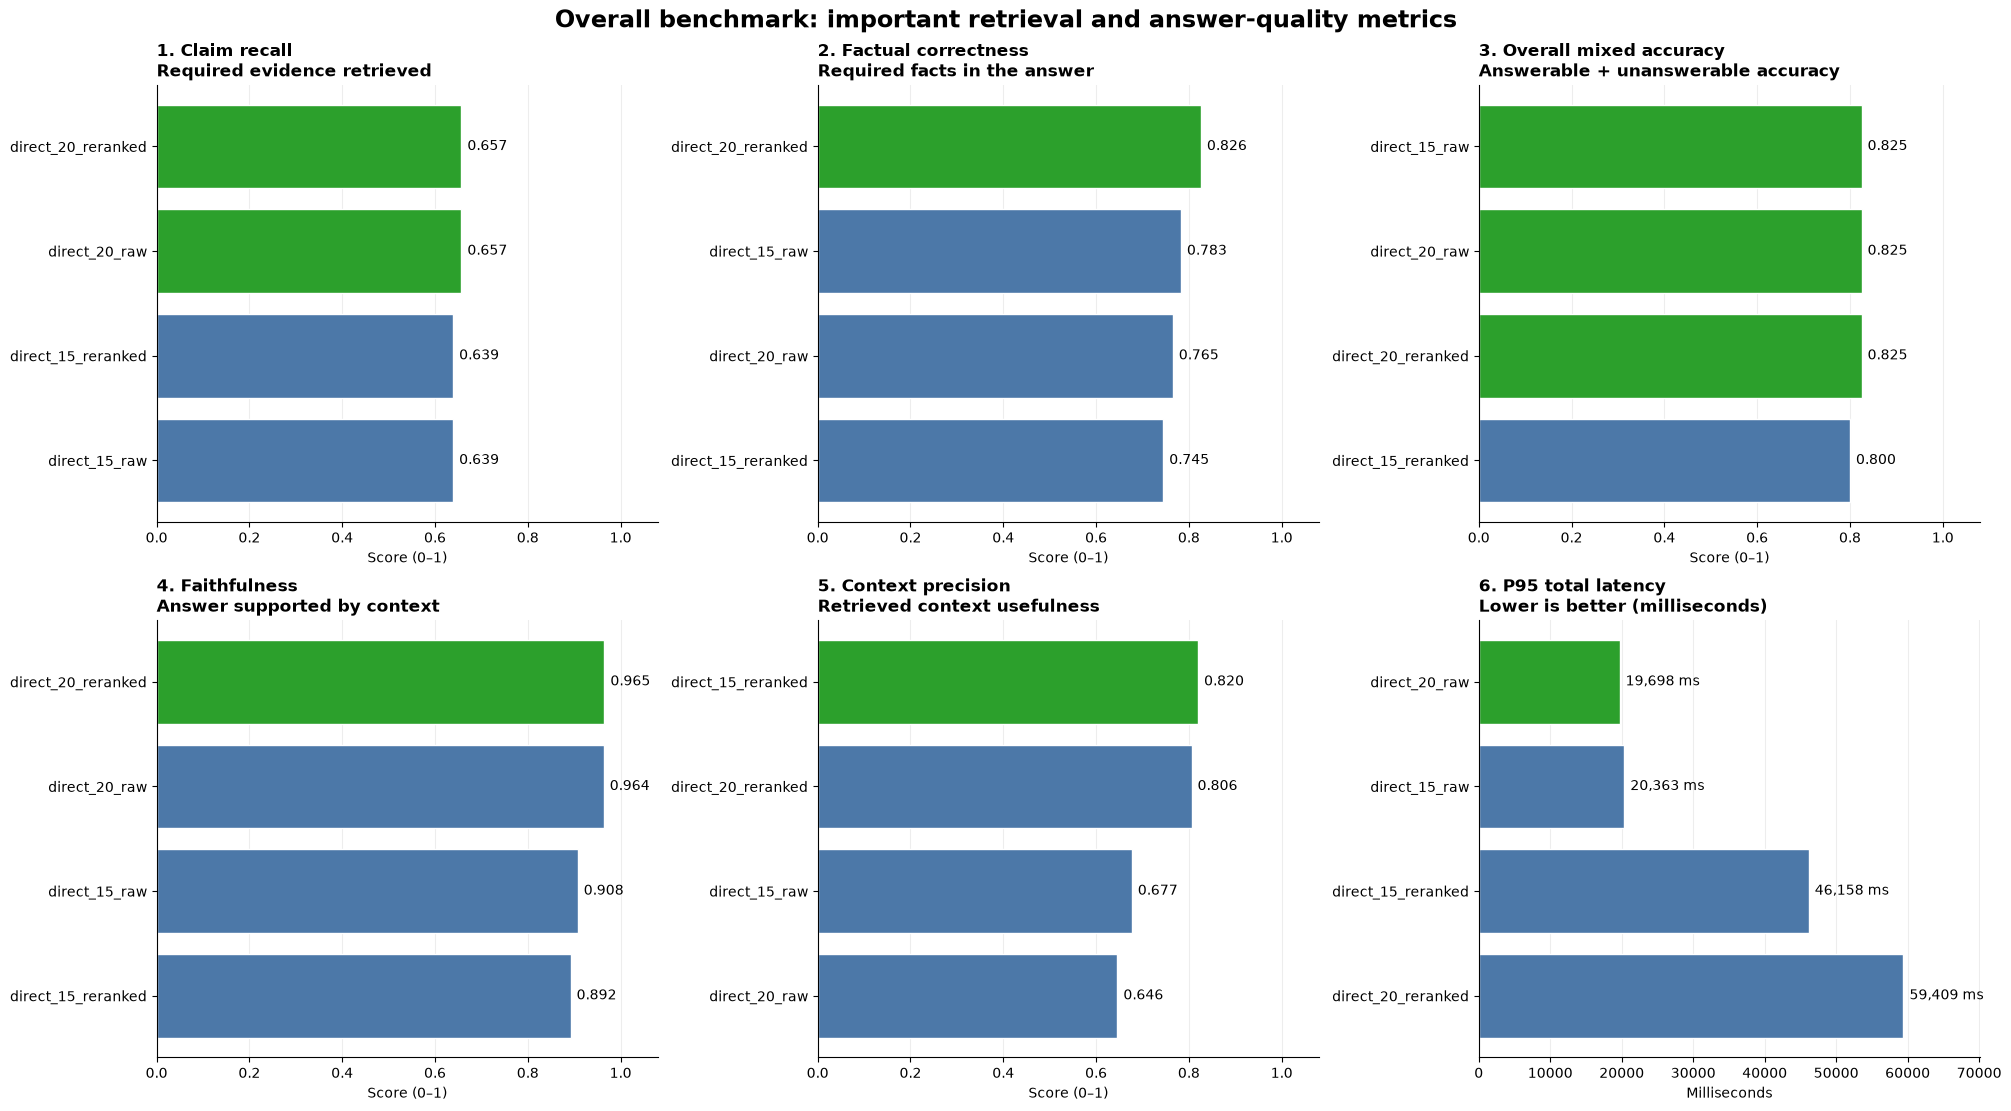

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Overall experiment-level metrics only. The order controls the subplot position.
important_metrics = [
    ("claim_recall", "1. Claim recall", True, "Required evidence retrieved"),
    ("mean_ragas_factual_correctness", "2. Factual correctness", True, "Required facts in the answer"),
    ("overall_mixed_accuracy", "3. Overall mixed accuracy", True, "Answerable + unanswerable accuracy"),
    ("mean_ragas_faithfulness", "4. Faithfulness", True, "Answer supported by context"),
    ("mean_ragas_context_precision", "5. Context precision", True, "Retrieved context usefulness"),
    ("p95_total_latency_ms", "6. P95 total latency", False, "Lower is better (milliseconds)"),
]

missing_metrics = [metric for metric, *_ in important_metrics if metric not in full_overall.columns]
if missing_metrics:
    raise KeyError(f"Missing required overall metrics: {missing_metrics}")

chart_data = full_overall[["variant"] + [metric for metric, *_ in important_metrics]].copy()
chart_data["variant"] = chart_data["variant"].astype(str)

fig, axes = plt.subplots(2, 3, figsize=(20, 11), constrained_layout=True)
base_color = "#4C78A8"
best_color = "#2CA02C"
missing_color = "#D9D9D9"

for ax, (metric, title, higher_is_better, subtitle) in zip(axes.flat, important_metrics):
    panel = chart_data[["variant", metric]].copy()
    panel[metric] = pd.to_numeric(panel[metric], errors="coerce")
    panel = panel.sort_values(metric, ascending=not higher_is_better, na_position="last").reset_index(drop=True)
    valid = panel[metric].notna()
    best_value = (panel.loc[valid, metric].max() if higher_is_better else panel.loc[valid, metric].min()) if valid.any() else np.nan
    colors = [
        missing_color if pd.isna(value) else best_color if np.isclose(value, best_value) else base_color
        for value in panel[metric]
    ]
    plot_values = panel[metric].fillna(0.0)
    bars = ax.barh(panel["variant"], plot_values, color=colors, edgecolor="white")
    ax.invert_yaxis()
    ax.set_title(f"{title}\n{subtitle}", loc="left", fontsize=12, fontweight="bold")
    ax.set_xlabel("Milliseconds" if metric.endswith("latency_ms") else "Score (0–1)")
    ax.grid(axis="x", alpha=0.22)
    ax.set_axisbelow(True)

    if not metric.endswith("latency_ms"):
        ax.set_xlim(0, 1.08)
    else:
        finite_max = panel.loc[valid, metric].max() if valid.any() else 1.0
        ax.set_xlim(0, max(float(finite_max) * 1.18, 1.0))

    for bar, value in zip(bars, panel[metric]):
        label = "N/A" if pd.isna(value) else f"{value:,.0f} ms" if metric.endswith("latency_ms") else f"{value:.3f}"
        x_position = 0.01 if pd.isna(value) else bar.get_width() + ax.get_xlim()[1] * 0.012
        ax.text(x_position, bar.get_y() + bar.get_height() / 2, label, va="center", fontsize=10)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

fig.suptitle("Overall benchmark: important retrieval and answer-quality metrics", fontsize=17, fontweight="bold")
plt.show()


## Full evaluation — category comparison (including Unanswerable)


In [9]:
# Category results reveal whether one configuration fails on a specific question type.
display(full_category[["category"] + full_primary_columns].style.format(full_formats, na_rep="N/A"))


,category,variant,candidate_cap,rerank,completed_questions,failed_questions,answerable_questions,unanswerable_questions,claim_recall,legacy_claim_recall,document_hit_rate,document_recall,mrr,mean_ragas_faithfulness,mean_ragas_factual_correctness,mean_ragas_context_precision,answerable_threshold_accuracy,abstention_accuracy,incorrect_abstention_rate,overall_mixed_accuracy,citation_validity_rate,mean_total_latency_ms,p95_total_latency_ms,mean_retrieval_latency_ms,mean_reranking_latency_ms,mean_prompt_latency_ms,mean_generation_latency_ms,mean_evaluation_latency_ms,mean_evaluation_saved_ms,mean_cache_load_ms,mean_wall_ms_this_execution,reconstructed_latency_questions,mean_candidate_count,mean_context_count,underfilled_questions,empty_pools,mean_generation_input_tokens,mean_generation_output_tokens,mean_generation_total_tokens,mean_embedding_tokens,mean_rag_total_tokens
0,Factual,direct_15_raw,15,False,8,0,8,0,0.974,0.868,1.000,1.000,1.000,1.000,0.927,0.711,1.000,N/A,0.000,1.000,1.000,6776.710,19940.381,2722.057,0.000,0.022,4054.632,2.664,89385.385,1.967,3.857,8,15.000,15.000,0,0,7964.125,233.500,8197.625,N/A,N/A
1,Factual,direct_15_reranked,15,True,8,0,8,0,0.974,0.868,1.000,1.000,1.000,1.000,0.938,0.899,1.000,N/A,0.000,1.000,1.000,31088.426,52330.003,2722.057,24301.222,0.022,4065.125,2.665,86088.597,2.352,4.138,8,15.000,15.000,0,0,7964.125,207.500,8171.625,N/A,N/A
2,Factual,direct_20_raw,20,False,8,0,8,0,0.974,0.868,1.000,1.000,1.000,1.000,0.922,0.653,1.000,N/A,0.000,1.000,1.000,4098.127,7527.344,480.997,0.000,0.025,3617.105,3.085,108615.609,2.263,4.525,8,20.000,20.000,0,0,10202.375,171.000,10373.375,N/A,N/A
3,Factual,direct_20_reranked,20,True,8,0,8,0,0.974,0.868,1.000,1.000,1.000,1.000,0.941,0.895,1.000,N/A,0.000,1.000,1.000,31363.207,37268.280,480.997,27679.785,0.025,3202.401,3.188,107590.393,2.677,4.810,8,20.000,20.000,0,0,10202.375,179.750,10382.125,N/A,N/A
4,Procedural,direct_15_raw,15,False,8,0,8,0,0.867,0.867,1.000,1.000,1.000,0.950,0.826,0.598,0.875,N/A,0.000,0.875,1.000,5204.057,7683.918,584.781,0.000,0.021,4619.255,2.519,106339.569,1.881,3.716,8,15.000,15.000,0,0,7647.125,343.125,7990.250,N/A,N/A
5,Procedural,direct_15_reranked,15,True,8,0,8,0,0.867,0.867,1.000,1.000,1.000,0.951,0.771,0.857,0.750,N/A,0.000,0.750,1.000,25809.557,33808.828,584.781,20268.954,0.021,4955.801,2.493,103855.841,2.175,3.793,8,15.000,15.000,0,0,7647.125,336.625,7983.750,N/A,N/A
6,Procedural,direct_20_raw,20,False,8,0,8,0,0.867,0.867,1.000,1.000,1.000,1.000,0.688,0.570,0.750,N/A,0.000,0.750,1.000,7608.041,15693.958,2839.879,0.000,0.030,4768.132,3.181,127261.778,2.329,4.807,8,20.000,20.000,0,0,10085.000,375.625,10460.625,N/A,N/A
7,Procedural,direct_20_reranked,20,True,8,0,8,0,0.867,0.867,1.000,1.000,1.000,0.994,0.857,0.859,0.875,N/A,0.000,0.875,1.000,39573.391,65083.075,2839.879,32295.311,0.027,4438.174,3.150,122170.430,2.690,4.812,8,20.000,20.000,0,0,10085.000,368.375,10453.375,N/A,N/A
8,Comparison,direct_15_raw,15,False,8,0,8,0,0.543,0.543,1.000,1.000,0.750,0.887,0.781,0.717,0.750,N/A,0.125,0.750,0.750,8616.703,19470.967,4322.232,0.000,0.024,4294.448,2.530,73460.802,1.931,3.739,8,15.000,15.000,0,0,7762.250,380.375,8142.625,N/A,N/A
9,Comparison,direct_15_reranked,15,True,8,0,8,0,0.543,0.543,1.000,1.000,0.750,0.823,0.771,0.731,0.875,N/A,0.125,0.875,0.875,27664.869,42221.572,4322.232,19280.921,0.025,4061.691,2.640,75517.079,2.365,4.118,8,15.000,15.000,0,0,7762.250,357.125,8119.375,N/A,N/A


# Conclusion 
Based on the benchmark results, **20 - No rerank** was selected as the baseline configuration. It provides the same overall mixed accuracy as the reranked configuration (0.825), while achieving substantially lower P95 latency (19.7s vs. 59.4s). It also achieves high claim recall (0.657) and faithfulness (0.964). Although reranking improves factual correctness and context precision, these gains come at a significant latency cost. Therefore, 20 no rerank provides a useful quality–latency trade-off for continuing the evaluation and application development.